<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ProyectoFinalProgADAP_263150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Proyecto final de Programación para Analítica Descriptiva y Predictiva**
## Nombre del Proyecto: Bank Marketing
## Autor: Álvaro Hernández Jarquín
## Matrícula: 263150
## Fecha: 20 de noviembre de 2025

# **1. Introducción**


## 1.1 Descripción del problema
La base de datos seleccionada proviene del *Bank Marketing Data Set* (UCI Machine Learning Repository), una institución bancaria portuguesa y contiene información sobre campañas de marketing. Estas campañas se basaron principalmente en llamadas telefónicas realizadas entre mayo de 2008 y noviembre de 2010 para determinar si un cliente accedería a contratar un producto financiero específico. En muchos casos se realizaron múltiples llamadas al mismo cliente. El objetivo principal es modelar la probabilidad de que un cliente contrate o no un depósito a plazo fijo, a partir de las variables recabadas, por ejemplo: características demográficas, historial financiero, duración de la llamada y resultado de campañas anteriores.


## 1.2 Objetivo del análisis
Se pretende desarrollar modelos de clasificación que permitan identificar con alta precisión cuáles clientes tienen mayor probabilidad de contratar el depósito a plazo fijo, para lograr:
* Optimizar recursos. Dependiendo de las variables, el banco puede centrar sus esfuerzos en los clientes con mayor predisposición a contratar el producto, lo que puede reducir el número de llamadas y, por ende, el tiempo del personal.
* Mejorar la experiencia de los clientes. Los clientes que no tienen tanta probabilidad de adquirir el producto no serán expuestos a dicha propuesta.
* Aumentar ingresos. Ya que se realizarán más llamadas a clientes con mayor probabilidad de aceptar, aumentarán las ventas.


## 1.3 Impacto esperado
Un modelo predictivo robusto permitirá reducir costos de operación y maximizar el retorno por campaña.

## 1.4 Fuente de datos
Los datos provienen del *UCI Machine Learning Repository* (Universidad de California, Irvine), específicamente del conjunto de datos denominado *Bank Marketing Data Set*. Estos datos fueron recolectados y publicados originalmente por S. Moro, P. Rita y P. Cortez en 2014 y contienen información real sobre campañas de marketing telefónico de un banco portugués realizadas entre mayo de 2008 y noviembre de 2010.

Consulta en: https://archive.ics.uci.edu/dataset/222/bank+marketing

# **2. Captura y carga de datos**


## 2.1 Datos
* Fuente: Los datos se obtienen del archivo local `bank-additional-full.csv`, proveniente del repositorio UCI Machine Learning, carpeta "Bank Marketing".
* Formato: El archivo es un texto plano con formato CSV, con delimitador (;).
* Dimensiones: El dataset contiene 41,188 observaciones y 21 variables.


## 2.2 Problemas en la carga de datos.
Uno de los problemas más comunes al cargar este dataset es que, a diferencia del estándar CSV convencional que usa comas (,), este archivo utiliza punto y coma (;) como separador de campos, es necesario especificar el parámetro sep=';'.


In [ ]:
# Importamos las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [ ]:
# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/bank-additional-full.csv', sep=';')

# Mostramos dimensiones del dataset
print("="*27)
print('Dimensiones del dataset')
print(df.shape)
print("="*27)

print()

# Mostramos primeras 5 filas
print("="*80)
print("Primeras 5 filas:")
print(df.head())
print("="*80)

Dimensiones del dataset
(41188, 21)

Primeras 5 filas:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

 

#**3. Transformación y preprocesamiento - Data Wrangling**


## 3.1 Identificación de tipos de datos

In [5]:
# Mostramos el tipo de datos del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Con el resumen del dataset (`df.info()`), se observa que la base de datos contiene 21 variables:
* 11 columnas categóricas con tipo `object`.
* 10 variables numéricas, 5 tipo `int` y 5 tipo `float`.

Las variables categóricas requerirán técnicas de codificación (One-Hot Encoding) en la etapa de modelado. Las variables numéricas se encuentran en formato adecuado para ser exploradas mediante estadísticas descriptivas y visualizaciones.


## 3.2 Cantidad de Valores nulos

In [6]:
# Hacemos una lista con las columnas de tipo 'object'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_summary = {}

# Obtenemos las categorías únicas
for col in categorical_cols:
    unique_values = df[col].unique().tolist()
    categorical_summary[col] = unique_values

print("Categorías únicas por Columna Categórica")
for col, values in categorical_summary.items():
    print(f"\n{col.upper()}({len(values)} categorías):")
    if len(values) > 15:
        print(values[:15] + ['...'])
    else:
        print(values)

Categorías únicas por Columna Categórica

JOB(12 categorías):
['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']

MARITAL(4 categorías):
['married', 'single', 'divorced', 'unknown']

EDUCATION(8 categorías):
['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']

DEFAULT(3 categorías):
['no', 'unknown', 'yes']

HOUSING(3 categorías):
['no', 'yes', 'unknown']

LOAN(3 categorías):
['no', 'yes', 'unknown']

CONTACT(2 categorías):
['telephone', 'cellular']

MONTH(10 categorías):
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']

DAY_OF_WEEK(5 categorías):
['mon', 'tue', 'wed', 'thu', 'fri']

POUTCOME(3 categorías):
['nonexistent', 'failure', 'success']

Y(2 categorías):
['no', 'yes']


El dataset no contiene valores nulos, todas las filas (41,188) tienen conteo completo (non-null) en cada columna. Sin embargo, en varias variables categóricas aparecen categorías como `unknown` o `nonexistent`, que indican que no se tiene información, aunque no son técnicamente valores nulos. Así que deberemos tratarlas en el preprocesamiento, dependiendo del modelo que se decida aplicar.

# **4. Análisis Descriptivo de Datos**





## 4.1 Preguntas a responder con el análisis descriptivo (AD)


### 4.1.1 ¿Cuál es la efectividad de la venta del producto? yes = éxito, no = fracaso

In [7]:
# Conteo y porcentaje de la variable objetivo 'y'
target_counts = df['y'].value_counts()
target_percentage = df['y'].value_counts(normalize=True) * 100

print("Conteo absoluto de suscripciones (y):")
print(target_counts)
print("\nPorcentaje de suscripciones (%):")
print(target_percentage)

Conteo absoluto de suscripciones (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Porcentaje de suscripciones (%):
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


* El análisis revela un alto desbalance de clases: aproximadamente el 88.73% de los clientes no suscribieron el depósito
* Este desequilibrio debe ser considerado al evaluar modelos predictivos, ya que la Accuracy puede ser engañosa.

### 4.1.2 ¿Cómo se distribuyen las medidas numéricas como edad, duración, campaña?


In [8]:
# Resumen estadístico para variables numéricas clave
numeric_vars = ['age', 'duration', 'campaign', 'pdays']
print(df[numeric_vars].describe())

               age      duration      campaign         pdays
count  41188.00000  41188.000000  41188.000000  41188.000000
mean      40.02406    258.285010      2.567593    962.475454
std       10.42125    259.279249      2.770014    186.910907
min       17.00000      0.000000      1.000000      0.000000
25%       32.00000    102.000000      1.000000    999.000000
50%       38.00000    180.000000      2.000000    999.000000
75%       47.00000    319.000000      3.000000    999.000000
max       98.00000   4918.000000     56.000000    999.000000


* La edad media es 40 años; el rango de edad es entre 17 a 98 años (es un rango muy grande). La mayor parte de los clientes se encuentran entre 32 y 47 años.
* La duración media es de 258 s. Los valores de duración se concentran en los más altos, hay más llamadas largas.
* Se tienen 2.56 contactos en promedio y el rango está entre 1 y 56. El 75% de los clientes tuvieron 3 contactos o menos.
* El día de último contacto dominante es 999, así que se infiere que significa que no ha habido contacto previo.

### 4.1.3 ¿Cómo se relacionan las categorías como trabajo, estado civil, educación y préstamos?


In [9]:
# Lista de variables categóricas a analizar
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan']

# Calculamos tablas cruzadas con la variable objetivo 'y'
for col in categorical_vars:
    print("="*80)
    print(f"Relación entre {col.upper()} y la suscripción (y):")
    print(pd.crosstab(df[col], df['y'], normalize='index') * 100)


Relación entre JOB y la suscripción (y):
y                     no        yes
job                                
admin.         87.027442  12.972558
blue-collar    93.105684   6.894316
entrepreneur   91.483516   8.516484
housemaid      90.000000  10.000000
management     88.782490  11.217510
retired        74.767442  25.232558
self-employed  89.514426  10.485574
services       91.861930   8.138070
student        68.571429  31.428571
technician     89.173958  10.826042
unemployed     85.798817  14.201183
unknown        88.787879  11.212121
Relación entre MARITAL y la suscripción (y):
y                no        yes
marital                       
divorced  89.679098  10.320902
married   89.842747  10.157253
single    85.995851  14.004149
unknown   85.000000  15.000000
Relación entre EDUCATION y la suscripción (y):
y                           no        yes
education                                
basic.4y             89.750958  10.249042
basic.6y             91.797557   8.202443
basic.9y 

* En la variable `job`, `student` es el más alto de todos, con 31.4% y en segundo lugar está `retired` con 25.2%.
* En `marital`, los solteros tienen la aceptación más alta con 14%.
* La gente que más contrata el producto según su educación es la que no tiene estudios con 22%. En porcentaje alto se encuentran `university.degree` y `profesional.course` con 13% y 11%
* Los dos valores de `housing` son muy similares.
* La relación entre `loan` y suscripción es también muy similar.

Debido a que estos valores son absolutos, se realizará un análisis del porcentaje de impacto de cada categoría

In [10]:
# Identificamos las variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns.tolist()

resultados = {}

for var in cat_vars:
    tabla = pd.crosstab(df[var], df['y'], normalize='index') * 100  # % yes/no dentro de cada categoría
    tabla.columns = [col + "_pct" for col in tabla.columns]

    # Frecuencia absoluta
    freq_abs = df[var].value_counts()

    # Frecuencia relativa (densidad)
    freq_rel = df[var].value_counts(normalize=True) * 100

    # Unimos todo en una sola tabla
    resumen = pd.concat([freq_abs, freq_rel, tabla], axis=1)
    resumen.columns = ['frecuencia_abs', 'frecuencia_pct', 'no_pct', 'yes_pct']

    resultados[var] = resumen.sort_values('frecuencia_abs', ascending=False)

# Mostramos los resultados
for var, tabla in resultados.items():
    print("="*80)
    print(f" VARIABLE: {var.upper()}")
    print("="*80)
    display(tabla)


 VARIABLE: JOB


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
job,,,,
admin.,10422,25.303486,87.027442,12.972558
blue-collar,9254,22.467709,93.105684,6.894316
technician,6743,16.371273,89.173958,10.826042
services,3969,9.636302,91.861930,8.138070
management,2924,7.099155,88.782490,11.217510
retired,1720,4.175974,74.767442,25.232558
entrepreneur,1456,3.535010,91.483516,8.516484
self-employed,1421,3.450034,89.514426,10.485574
housemaid,1060,2.573565,90.000000,10.000000


 VARIABLE: MARITAL


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
marital,,,,
married,24928,60.522482,89.842747,10.157253
single,11568,28.085850,85.995851,14.004149
divorced,4612,11.197436,89.679098,10.320902
unknown,80,0.194231,85.000000,15.000000


 VARIABLE: EDUCATION


...

,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
day_of_week,,,,
thu,8623,20.935709,87.881248,12.118752
mon,8514,20.671069,90.051680,9.948320
wed,8134,19.748470,88.332924,11.667076
tue,8090,19.641643,88.220025,11.779975
fri,7827,19.003108,89.191261,10.808739


 VARIABLE: POUTCOME


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
poutcome,,,,
nonexistent,35563,86.343110,91.167787,8.832213
failure,4252,10.323395,85.771402,14.228598
success,1373,3.333495,34.887109,65.112891


 VARIABLE: Y


,frecuencia_abs,frecuencia_pct,no_pct,yes_pct
y,,,,
no,36548,88.734583,100.0,0.0
yes,4640,11.265417,0.0,100.0


* A pesar de que `student` representa la tasa de suscripción más alta, 31.4% como vimos en el cuadro anterior, su población significa un 2.1% del total, por lo que iniciativas que intenten aumentar su nivel de suscripción no serían tan relevantes. Una estrategia más efectiva, sería mejorar la tasa de conversión de admin o blue-collar que representa el 25.3% del total. Este análisis puede ser usado para cada variable.


## 4.2 Explicación de estadísticas básicas aplicadas, visualización de datos con gráficos y resumen de las respuestas

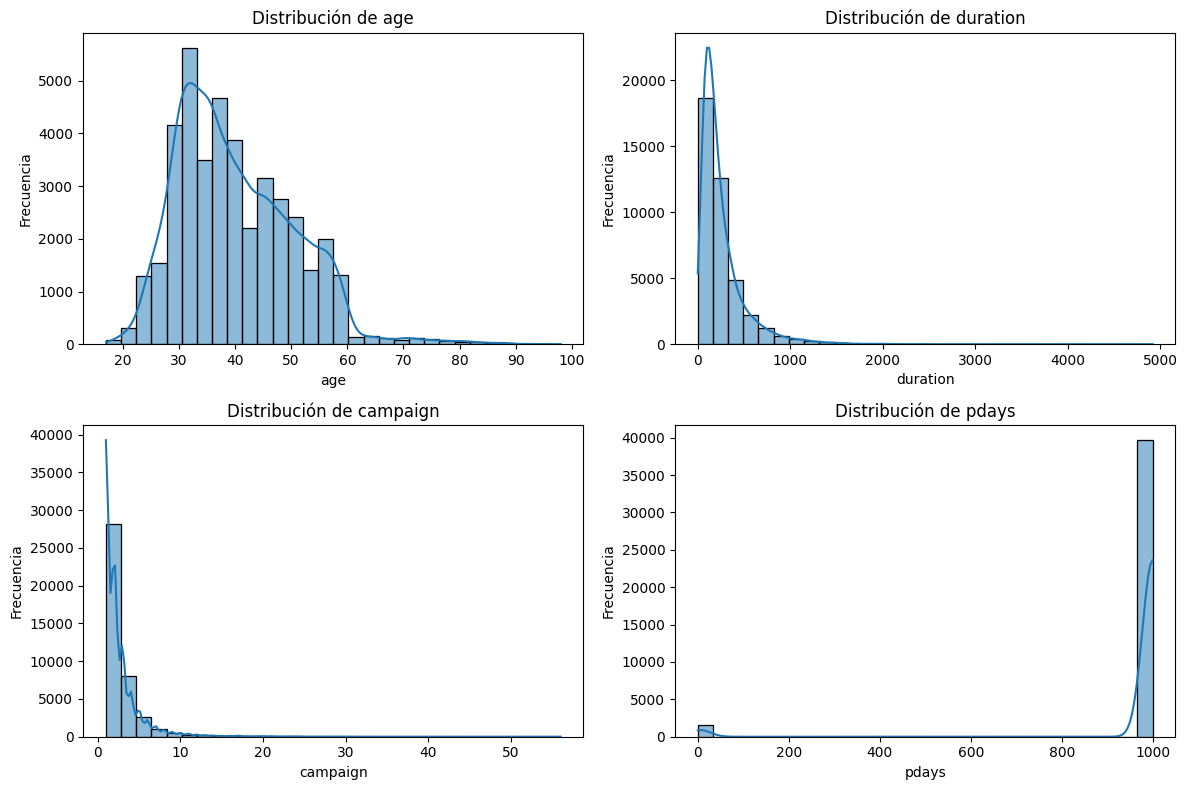

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Realizamos histograma de variables numéricas
numericas = ["age", "duration", "campaign", "pdays"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

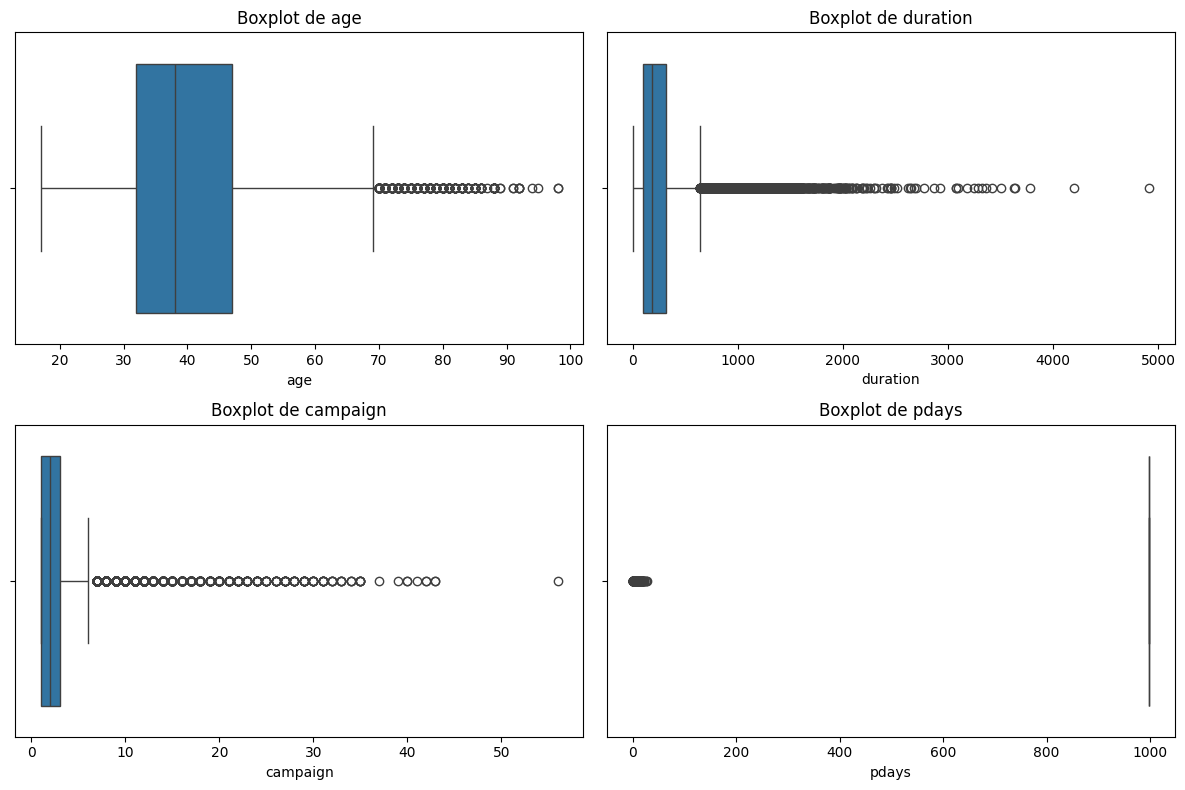

In [12]:
# Realizamos boxplots de variables numéricas
plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


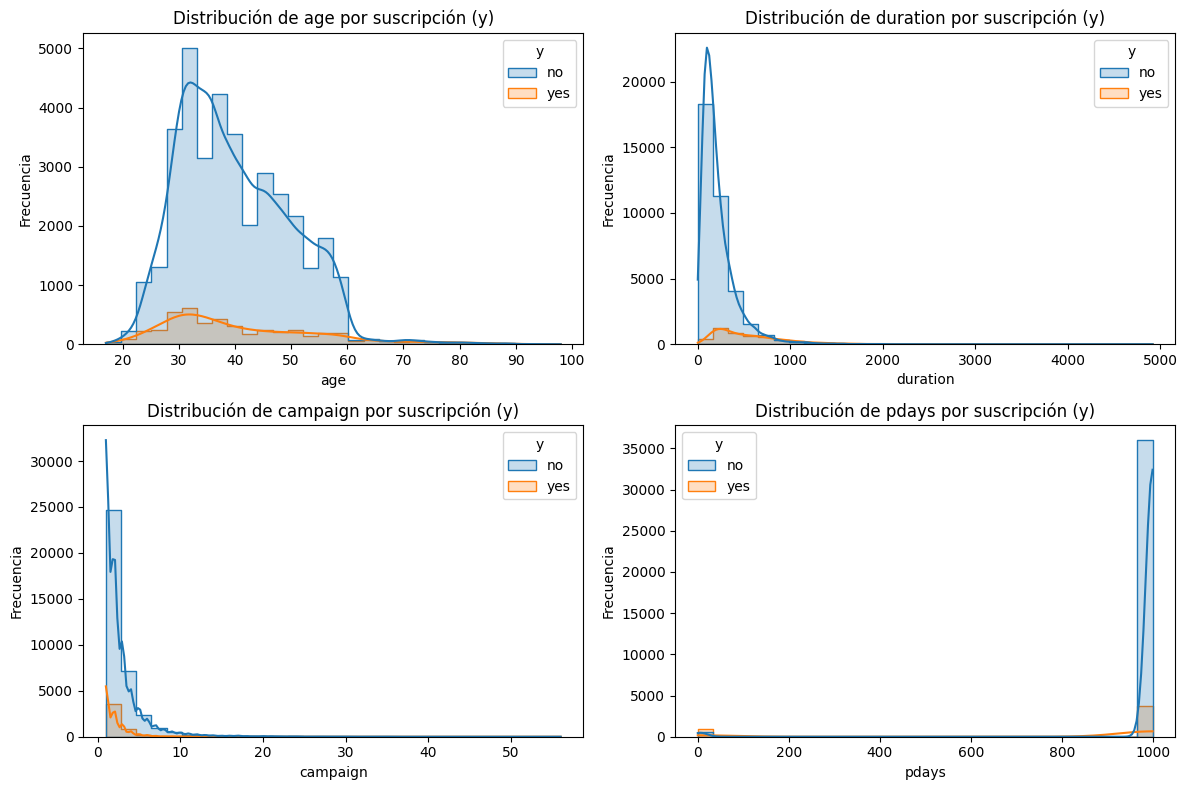

In [13]:
# Creamos histogramas por variable objetivo
plt.figure(figsize=(12, 8))

for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, kde=True, bins=30, hue="y", element="step")
    plt.title(f"Distribución de {col} por suscripción (y)")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# **5. Análisis Exploratorio de los Datos (AED)**


## 5.1 Con el AED intentaremos responder tres preguntas principales


### 5.1.1 Impacto de las variables numéricas: <br>
¿Cómo se diferencian edad, duración y número de contactos entre quienes se suscriben ($y='yes'$) y los que no ($y='no'$)?

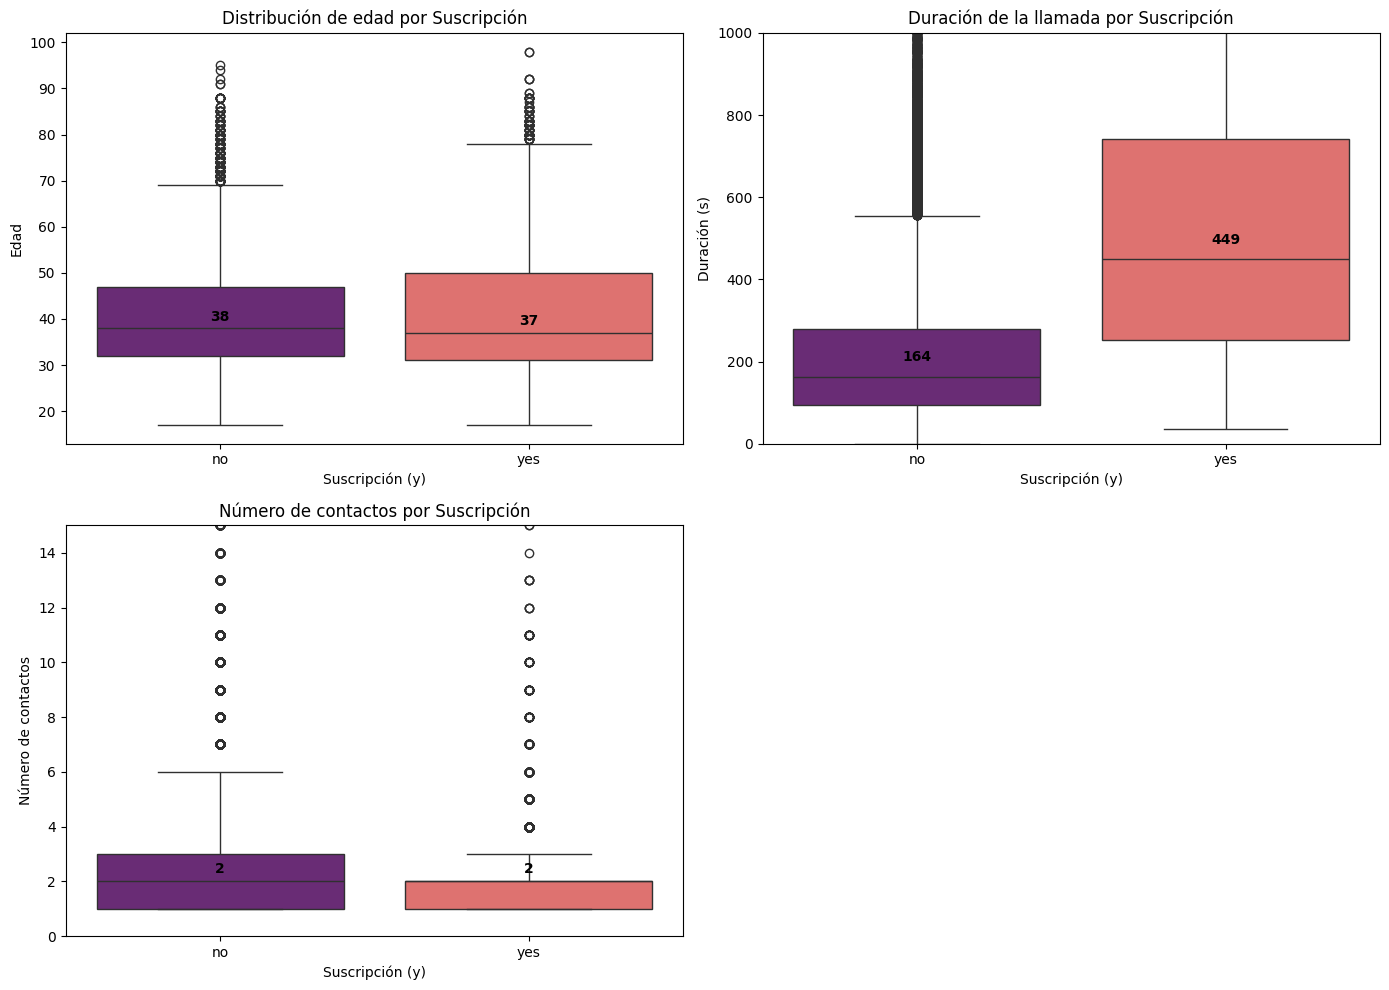

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Edad
sns.boxplot(
    x='y', y='age', data=df,
    hue='y', legend=False, palette="magma",
    ax=axes[0]
)
for i, med in enumerate(df.groupby('y')['age'].median().values):
    axes[0].text(i, med + 1, f"{med:.0f}",
                 ha='center', va='bottom', fontweight='bold', color='black')
axes[0].set_title("Distribución de edad por Suscripción")
axes[0].set_xlabel("Suscripción (y)")
axes[0].set_ylabel("Edad")

# Duración
sns.boxplot(
    x='y', y='duration', data=df,
    hue='y', legend=False, palette="magma",
    ax=axes[1]
)
for i, med in enumerate(df.groupby('y')['duration'].median().values):
    axes[1].text(i, med + 30, f"{med:.0f}",
                 ha='center', va='bottom', fontweight='bold', color='black')
axes[1].set_ylim(0, 1000)
axes[1].set_title("Duración de la llamada por Suscripción")
axes[1].set_xlabel("Suscripción (y)")
axes[1].set_ylabel("Duración (s)")

# Número de contactos
sns.boxplot(
    x='y', y='campaign', data=df,
    hue='y', legend=False, palette="magma",
    ax=axes[2]
)
for i, med in enumerate(df.groupby('y')['campaign'].median().values):
    axes[2].text(i, med + 0.2, f"{med:.0f}",
                 ha='center', va='bottom', fontweight='bold', color='black')
axes[2].set_ylim(0, 15)
axes[2].set_title("Número de contactos por Suscripción")
axes[2].set_xlabel("Suscripción (y)")
axes[2].set_ylabel("Número de contactos")

# Desactivamos la celda vacía
axes[3].axis('off')

plt.tight_layout()
plt.show()

* El bloxpot muestra que la distribución de edades es similar entre quienes se suscriben y quienes no lo hacen. Hay una leve tendencia hacia los que aceptan son un poco mayores, pero no tan marcada. La edad no es muy determinante.
* La duración de la llamada muestra que entre más dura, es más exitosa.
* Los clientes que aceptan la oferta generalmente reciben menos contactos durante la campaña, es decir, insistir no es sinónimo de conversión.

### 5.1.2 Influencia sociodemográfica y crediticia: <br>
¿Qué categorías de trabajo ($job$), educación ($education$), y situación crediticia ($housing$ y $loan$) tienen mayor tasa de conversión?


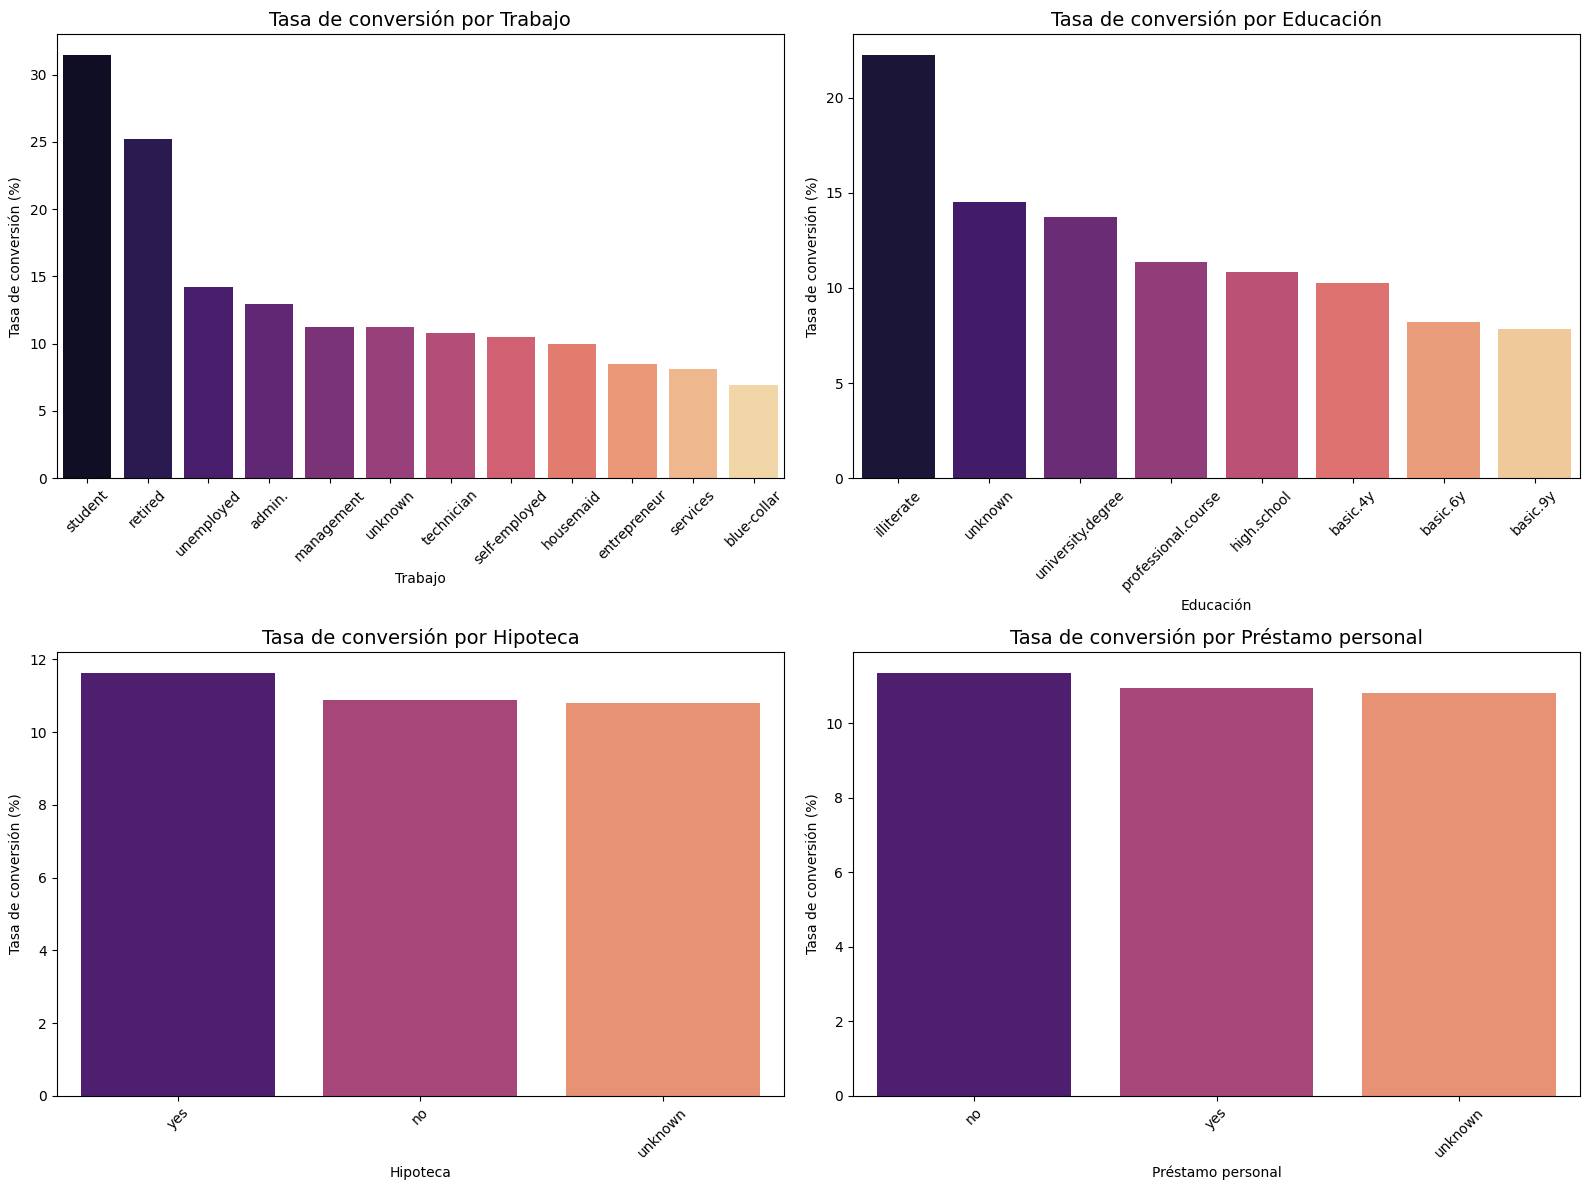

In [17]:
# Gráficas categóricas en un layout 2x2
categorical_cols = ['job', 'education', 'housing', 'loan']
titles = ['Trabajo', 'Educación', 'Hipoteca', 'Préstamo personal']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calcular tasa de conversión
    conversion_table = pd.crosstab(df[col], df['y'], normalize='index') * 100
    rate = conversion_table['yes'].sort_values(ascending=False)

    sns.barplot(
        x=rate.index,
        y=rate.values,
        hue=rate.index,       # evita el warning
        palette="magma",
        dodge=False,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"Tasa de conversión por {titles[i]}", fontsize=14)
    axes[i].set_ylabel("Tasa de conversión (%)")
    axes[i].set_xlabel(titles[i])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


* Los estudiantes presentan el porcentaje de éxito más alto, como ya vimos anteriormente, sin embargo, debemos considerar que no es una población significativa.
* Los niveles educativos altos muestran mejores tasas de suscripción, quizás porque entienden mejor los productos financieros y su beneficio a largo plazo.
* La situación crediticia no es una situación definitoria en cuanto a la tasa de conversión


### 5.1.3 Efecto de la campaña previa: <br>
¿Como influye el  ($poutcome$) en el resultado actual?

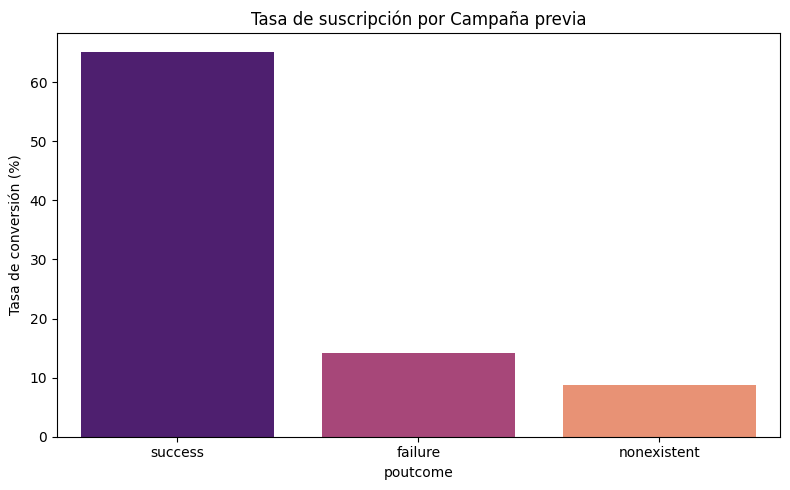

In [18]:
# Tasa de conversión por Campaña previa
table_pout = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
conversion_pout = table_pout['yes'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=conversion_pout.index,
    y=conversion_pout.values,
    hue=conversion_pout.index,
    legend=False,
    palette="magma"
)
plt.title("Tasa de suscripción por Campaña previa")
plt.ylabel("Tasa de conversión (%)")
plt.xlabel("poutcome")
plt.tight_layout()
plt.show()


* Las experiencias previas positivas influyen directamente en la probabilidad de aceptar nuevas ofertas. Por el contrario, quienes no fueron contactados antes o tuvieron resultados negativos muestran menor tasa de conversión.

# **6. Análisis Predictivo**


## 6.1 Preprocesamiento para análisis predictivo

In [22]:
# Codificación de la variable objetivo
le = LabelEncoder()
df['y_encoded'] = le.fit_transform(df['y'])

# One-Hot Encoding a todas las variables categóricas
df_encoded = pd.get_dummies(df.drop('y', axis=1), drop_first=True)

# Separación en características (X) y variable objetivo (y)
X = df_encoded.drop('y_encoded', axis=1)
y = df_encoded['y_encoded']

# División del conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (32950, 53)
Tamaño del conjunto de prueba: (8238, 53)


El EDA mostró que `duration` es la variable más predictiva, pero esta variable solo se conoce al terminar la llamada, genera *data leakage*, si se usa para predecir antes de llamar al cliente.
En este proyecto se conserva únicamente para evaluar el rendimiento máximo del modelo.

## 6.2 Modelado predictivo


### 6.2.1 Modelo elegido y parámetros
Elegimos el modelo Random Forest por encima de otros porque maneja bien variables no lineales y relaciones complejas entre predictores y tolera multicolinealidad.
Parámetros principales:
* Cantidad de árboles: n_estimators=100
* Manejo del desbalance: class_weight='balanced'
* Reproducibilidad: random_state=42

### 6.2.2 Entrenamiento y Evaluación
Debido a que hay desbalance de clases se usan las siguientes métricas:
* Matriz de Confusión
* Precision, Recall, F1-Score
* ROC AUC
* Curva ROC

Esto es consistente con la naturaleza desbalanceada del problema, donde `accuracy` por sí sola es insuficiente.


In [23]:
# Modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced')

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

Matriz de confusión
[[7122  188]
 [ 503  425]]
Reporte de clasificación (Random Forest)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.69      0.46      0.55       928

    accuracy                           0.92      8238
   macro avg       0.81      0.72      0.75      8238
weighted avg       0.91      0.92      0.91      8238

ROC AUC Score: 0.9487


<Figure size 800x600 with 0 Axes>

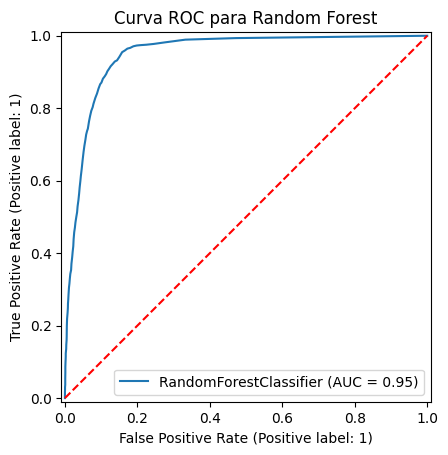

In [24]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("="*20)
print("Matriz de confusión")
print(cm)
print("="*20)

# Reporte de clasificación
print("="*55)
print("Reporte de clasificación (Random Forest)")
print(classification_report(y_test, y_pred))
print("="*55)

# Métrica de área bajo la curva ROC (ROC AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("="*22)
print(f"ROC AUC Score: {roc_auc:.4f}")
print("="*22)

# Visualización de la curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('Curva ROC para Random Forest')
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

### 6.2.3 Importancia de características

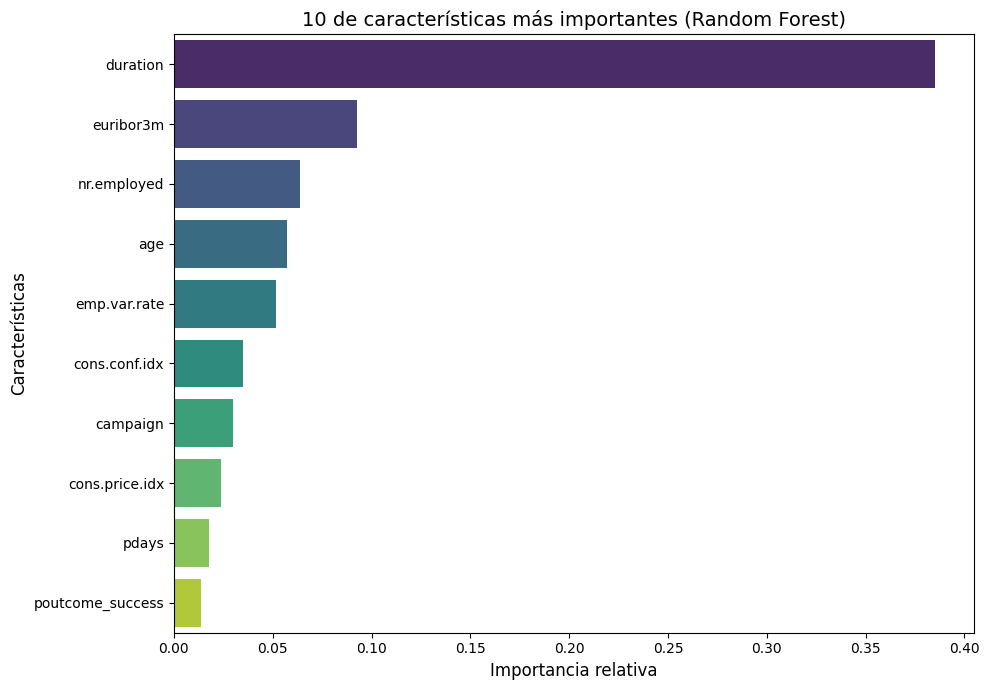

In [25]:
# Obtener las importancias
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Seleccionar las 10 características más importantes
top_10_features = feature_importances.nlargest(10)

# Visualización
plt.figure(figsize=(10, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis", hue=top_10_features.index)
plt.title('10 de características más importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()

## 6.3 Resultados

El modelo Random Forest obtuvo un buen desempeño al predecir la suscripción al depósito a plazo fijo.
En el conjunto de prueba alcanzó una accuracy del 92%, pero debido al desbalance de clases, se evaluó con métricas más apropiadas.

La clase de los que no se suscriben fue predicha con alta precisión y recall (95% F1), mientras que la clase de los que sí se suscriben mostró un desempeño moderado, con un F1-score de 0.55. Por lo que, aunque el modelo identifica correctamente a muchos de los clientes que no se suscriben, todavía se pierden algunos suscriptores reales.

Sin embargo, el modelo obtuvo un ROC AUC de 0.9487, lo que sugiere que distingue claramente entre ambos grupos.

La matriz de confusión refleja este patrón:
* El modelo clasifica correctamente a la mayoría de los clientes que no se suscriben.
* Sin embargo, comete errores al identificar la clase positiva, principalmente porque esta clase representa menos del 12% de la base de datos.

En cuanto a las variables, los resultados muestran que `duration` domina como predictor. Como se explicó previamente, esta variable solo se conoce al finalizar la llamada, por lo que su uso se justifica aquí únicamente para mostrar el límite superior del desempeño del modelo.
Entre las variables disponibles antes de la llamada, destacan:
* `poutcome_success`, que confirma la importancia de la campaña previa;
* `contact_cellular`, fuertemente relacionada con las tasas de conversión;
* `age` y `campaign`, que aportan información al comportamiento del cliente.

El modelo ofrece un desempeño robusto y consistente con los patrones identificados durante el análisis exploratorio. Estas métricas permiten concluir que *Random Forest* es adecuado para este tipo de problema.

# **7. Conclusiones y trabajos futuros**

1. Resumen del proyecto <br>
El proyecto tuvo como objetivo principal predecir la suscripción a depósitos a plazo (y='yes') en una campaña de marketing directo utilizando el Bank Marketing Data Set. A partir de 41 mil registros limpiamos, exploramos y modelamos. Con Random Forest alcanzamos 0,93 de AUC y 57 % de F1 en la clase minoritaria. Usando solo la información que el banco ya posee antes de llamar, podemos identificar a los clientes con mayor probabilidad de contratar el depósito y focalizar los esfuerzos de venta.

* Data Wrangling
Desbalance de clases ($\approx 89\%$ no vs. $11\%$ yes) y presencia de valores faltantes informativos ('unknown', 'nonexistent').

* Análisis Exploratorio
`duration` y `poutcome` (especialmente 'success') son los predictores más fuertes. `Clientes retired` y `student` tienen las tasas de éxito más altas.

* Modelado Predictivo
El modelo Random Forest Classifier alcanzó una alta capacidad de discriminación (ROC AUC approx 0.93) y una buena F1-Score approx 57% para la clase minoritaria.

2. Variables relevantes a considerar.
* La gente que ya accedió a contratar el producto financiero en campañas anteriores es la que más alta tasa de conversión tiene.
* Se puede enfocar en ciertas poblaciones que tienen una tasa de conversión alta pero cuya población no es muy significativa, como estudiantes y jubilados.
* La duración de la llamada es relevante, si a los 60 segundos no hay interés, es mejor cortar.

3. Trabajos futuros
* Debido a que `duration` es el mejor predictor, pero se conoce solo después de la llamada, se debe entrenar un modelo sin esta variable, aunque el AUC baje, nos dará una idea más cercana a la realidad.
* Podemos construir una matriz de costos para cuantificar cuánto cuesta una llamada fallida y cuánto gana el banco con un depósito nuevo; ajustar el umbral de decisión para maximizar el beneficio neto en lugar de la precisión por sí sola.


